### Disclaimer : we'll only work with the onset state as target (s=1), and set the s=2 as 0


In [46]:
import numpy as np
import pandas as pd
from hmmlearn import hmm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import ConfusionMatrixDisplay as plot_cm
import matplotlib.pyplot as plt
import datetime as dt
import sys
from scipy.signal import medfilt
from pathlib import Path
sys.path.append(f"{Path.home()}/pavnet-v3/vlfcode/")
#sys.path.append("/home/aldo/maestria/tesis/vlf/code/")
from sxrf_download import sunpy_xrf
from sklearn.metrics import classification_report, confusion_matrix
from scipy import signal
#xr_df = sunpy_xrf("2025-01-1 12:00", "2025-08-26 21:59", sat_number=18)
import hmmlearn
import modelutils as mu 
from statsmodels.tsa.regime_switching.markov_autoregression import MarkovAutoregression as mar



In [47]:


# df = pd.read_csv(...) 
df1 = pd.read_csv("vlf_trainingdata_2025_piu.csv", index_col=[0],parse_dates=[0])
df2 = pd.read_csv("vlf_test_2026_piu.csv", index_col=[0],parse_dates=[0])
#df2.rename(columns={"GOES-18_long": "GOES18"}, inplace=True)
df2.drop(columns=["GOES-18_long"], inplace=True)
#df2.columns = [ "NAA","GOES18" ,"state" ,"GOES19", "flare_class"]
_df2 = df2[ ["NAA","GOES18" ,"state" ,"GOES19"]]
_df1 = df1[ ["NAA","GOES18" ,"state" ,"GOES19"]]
#df = df1.join(df2[[ "NAA","GOES18" ,"GOES18" ,"state" ,"GOES19"]], how="left")
# Drop duplicate rows within each DataFrame (keep first occurrence per timestamp)
_df1 = _df1[~_df1.index.duplicated(keep='first')]
_df2 = _df2[~_df2.index.duplicated(keep='first')]

# Now concatenate and drop duplicates across the combined set
combined = pd.concat([_df1, _df2])
df = combined[~combined.index.duplicated(keep='first')]  # or keep='last'
# set state decay (2) as normal (0)
df.loc[df["state"]==2, "state"] = 0

In [48]:
df.columns

Index(['NAA', 'GOES18', 'state', 'GOES19'], dtype='object')

In [49]:
lowp = signal.firwin(101, 0.01, fs=1/10)
df[f"NAA-filt"] = signal.filtfilt(lowp, 1, df["NAA"].values)
#df['NAA_dB'] = 20 * np.log10(df['NAA-filt'] + 1e-9)
# derivada o velocidad de cambio

df.head()

df.loc[:, 'NAA'] = df['NAA'].clip(lower=-10)
background = df['NAA'].rolling(window=60, center=False).min()
df["NAA_dB_bgrm"] = df["NAA"]-background #brackground removed
df['Delta'] = df['NAA'].diff(5).fillna(0)

/tmp/ipykernel_15864/2778029941.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[f"NAA-filt"] = signal.filtfilt(lowp, 1, df["NAA"].values)
/tmp/ipykernel_15864/2778029941.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["NAA_dB_bgrm"] = df["NAA"]-background #brackground removed
/tmp/ipykernel_15864/2778029941.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documenta

In [50]:
df2.columns

Index(['NAA', 'GOES18', 'state', 'GOES19', 'flare_class'], dtype='object')

In [51]:

df["time"] = df.index.time
df["date"] = df.index.date
pivotdf = df.pivot(values="NAA", columns="time", index="date")#.dropna()
pivot_qdc = pivotdf.rolling(window=27, center=False, min_periods=2).median()
# removing the QDC  mask
qdc_refcurve = pivot_qdc.unstack().swaplevel().sort_index()
qdc_refcurve.index = [dt.datetime.combine(qdc_refcurve.index[i][0], qdc_refcurve.index[i][1]) for i in range(len(qdc_refcurve))]
df["qdc_ref"] = qdc_refcurve
# Actualizacion: cambio de X, X= [delta(background removed) , diff(periods=5)]
df["delta_amp"] = df["NAA"] - df["qdc_ref"]
df['diff_amp'] = df['delta_amp'].diff(5).fillna(0)




/tmp/ipykernel_15864/3694190074.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["time"] = df.index.time
/tmp/ipykernel_15864/3694190074.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["date"] = df.index.date
/tmp/ipykernel_15864/3694190074.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.

In [52]:
amp = df["delta_amp"]

# Multi-scale slopes
# df["slope_1m"]  = amp.diff(6)          # 1 min
df["slope_5m"]  = amp.diff(5)         # 5 min
df["slope_10m"] = amp.diff(10)         # 15 min

# Local "transient" feature: how far is the current sample from its 30-min median
df["transient"] = amp - amp.rolling(180, center=False, min_periods=60).median()

# Rolling volatility (onsets increase high-frequency power)
df["rv_5m"] = amp.rolling(30).std()

/tmp/ipykernel_15864/1935954355.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["slope_5m"]  = amp.diff(5)         # 5 min
/tmp/ipykernel_15864/1935954355.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["slope_10m"] = amp.diff(10)         # 15 min
/tmp/ipykernel_15864/1935954355.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org

In [53]:
from scipy.signal import butter, filtfilt
b, a = butter(4, [1/(30), 1/(3)], btype='band', fs=1/1)  # 3–30 min band
df["bp_energy"] = filtfilt(b, a, df["delta_amp"].fillna(0))**2

/tmp/ipykernel_15864/1612259341.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["bp_energy"] = filtfilt(b, a, df["delta_amp"].fillna(0))**2


In [30]:
%matplotlib qt

In [54]:
# local background
# 60 min
win         = "60min"
min_periods = 20
df["bg_local_60min"] = (
    df["NAA"]
        .rolling(win, center=False, min_periods=min_periods)
        .median()
)
df["bg_local_60min"] = df["bg_local_60min"].fillna(df["qdc_ref"])
df["delta60min_amp_local"] = df["NAA"] - df["bg_local_60min"]
df["diff60min_amp_local"] = df["delta60min_amp_local"].diff(5).fillna(0)

# 120 min
win         = "120min"
min_periods = 20
df["bg_local_120min"] = (
    df["NAA"]
        .rolling(win, center=False, min_periods=min_periods)
        .median()
)
df["bg_local_120min"] = df["bg_local_120min"].fillna(df["qdc_ref"])
df["delta120min_amp_local"] = df["NAA"] - df["bg_local_120min"]
df["diff120min_amp_local"] = df["delta120min_amp_local"].diff(5).fillna(0)

/tmp/ipykernel_15864/1720415981.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["bg_local_60min"] = (
/tmp/ipykernel_15864/1720415981.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["bg_local_60min"] = df["bg_local_60min"].fillna(df["qdc_ref"])
/tmp/ipykernel_15864/1720415981.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/

In [10]:

df.head()

,NAA,GOES18,state,GOES19,NAA-filt,NAA_dB_bgrm,Delta,time,date,qdc_ref,...,slope_10m,transient,rv_5m,bp_energy,bg_local_60min,delta60min_amp_local,diff60min_amp_local,bg_local_120min,delta120min_amp_local,diff120min_amp_local
2024-12-17 00:00:00,NaN,NaN,0.0,0.000002,NaN,NaN,0.0,00:00:00,2024-12-17,NaN,...,NaN,NaN,NaN,8.157485e-154,NaN,NaN,0.0,NaN,NaN,0.0
2024-12-17 00:01:00,NaN,NaN,0.0,0.000002,NaN,NaN,0.0,00:01:00,2024-12-17,NaN,...,NaN,NaN,NaN,1.086008e-153,NaN,NaN,0.0,NaN,NaN,0.0
2024-12-17 00:02:00,NaN,NaN,0.0,0.000002,NaN,NaN,0.0,00:02:00,2024-12-17,NaN,...,NaN,NaN,NaN,1.327559e-153,NaN,NaN,0.0,NaN,NaN,0.0
2024-12-17 00:03:00,NaN,NaN,0.0,0.000002,NaN,NaN,0.0,00:03:00,2024-12-17,NaN,...,NaN,NaN,NaN,1.497166e-153,NaN,NaN,0.0,NaN,NaN,0.0
2024-12-17 00:04:00,NaN,NaN,0.0,0.000002,NaN,NaN,0.0,00:04:00,2024-12-17,NaN,...,NaN,NaN,NaN,1.554474e-153,NaN,NaN,0.0,NaN,NaN,0.0


In [55]:
# plot

%matplotlib qt
fig = plt.figure()
ax = plt.subplot(311)
ax.plot(df["delta_amp"], label="delta amp", color="red", alpha=0.7)
ax.plot(df["delta60min_amp_local"], label="delta amp loc 60", color="blue", alpha=0.7)
ax.plot(df["delta120min_amp_local"], label="delta amp loc 120", color="magenta", alpha=0.7)
ax2 = ax.twinx()
ax2.plot(df["GOES18"], label="RX", color="k", alpha=.5)
ax2.set_yscale("log")
ax.legend(); ax2.legend()
ax.grid(axis="x", ls="--")
ax = plt.subplot(312, sharex=ax)
ax.plot(df["slope_5m"], color="red", label="slope 5m", alpha=.6)
# ax.plot(df["slope_10m"], label="slope 5m", alpha=.6)
ax.plot(df["diff60min_amp_local"],color = "blue", label="diff delta 60", alpha=.6)
ax.plot(df["diff120min_amp_local"], color="magenta", label="diff delta 120", alpha=.6)
ax.legend();
ax.grid(axis="x", ls="--")
ax = plt.subplot(313, sharex=ax)
ax.plot(df["transient"], label="transient")
ax.legend()
ax.grid(axis="x", ls="--")
# ax = plt.subplot(414, sharex=ax)
# ax.plot(df["bp_energy"], label="bp_energy")
# ax.legend()
# ax.grid(axis="x", ls="--")
# ax.set_yscale("log")
ax.set_xlim(dt.datetime(2025, 4, 4,12), dt.datetime(2025, 4, 5))
fig.autofmt_xdate()
plt.subplots_adjust(hspace=0.5)
plt.show()

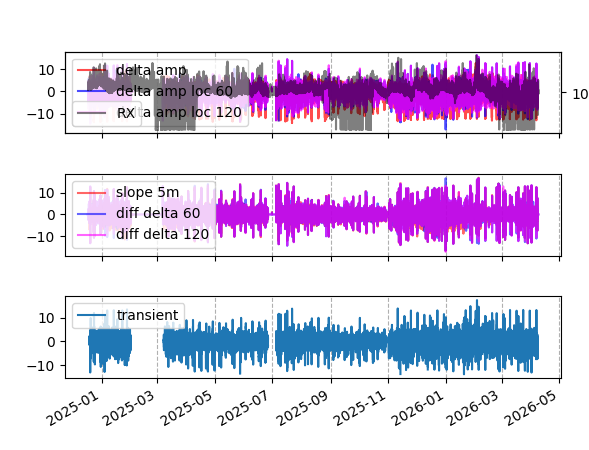

In [12]:
# plt.figure()
# df["diff60min_amp_local"].plot()
sum(df["diff60min_amp_local"]  == df["diff120min_amp_local"]) , sum(df["diff60min_amp_local"]  != df["diff120min_amp_local"]) 

(98943, 589377)

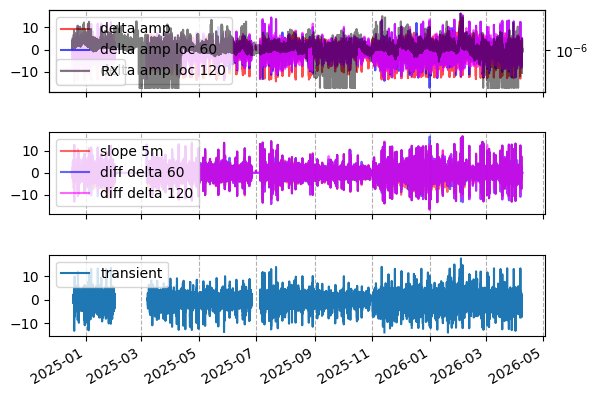

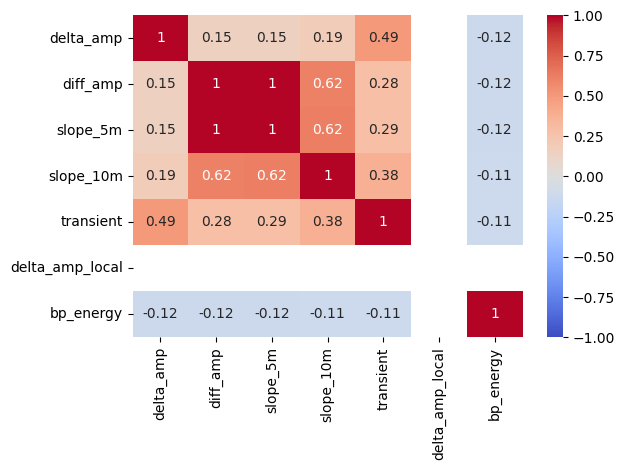

In [13]:
%matplotlib inline
import seaborn as sns
feat_names=["delta_amp", "diff_amp", "slope_5m", "slope_10m", "transient",  "delta_amp_local","bp_energy"]

corr = pd.DataFrame(df, columns=feat_names).corr()
fig = plt.figure()
sns.heatmap(corr, annot=True, vmin=-1, vmax=1, cmap="coolwarm")
plt.tight_layout()

In [60]:
dl1,dl2 = dt.datetime(2025,4,4,12), dt.datetime(2025,4,6)
#df[["delta_amp","diff_amp"]].plot()
fig, axs = plt.subplots(2,1,sharex=True)
ax=axs[0]

df.loc[dl1:dl2, ["NAA","qdc_ref"]].plot(ax=ax)
# plt.xlim(dl1, dl2)
ax=axs[1]

df.loc[dl1:dl2, ["state"]].plot(ax=ax)
# plt.xlim(dl1, dl2)
#plt.axvspan(rx_suntimes[dl1.date][0], color="yellow")
#plt.axvspan(*rx_suntimes[(dl2-dt.timedelta(days=1)).date()], color="yellow")

<Axes: >

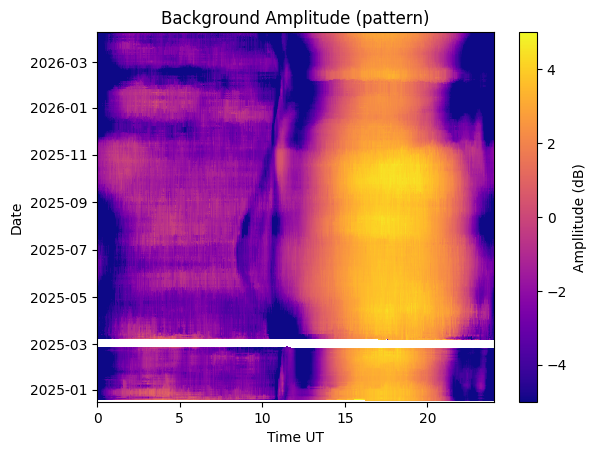

In [16]:

time_arr = np.linspace(0,24, len(pivot_qdc.columns))

fig, ax = plt.subplots()
im = ax.pcolormesh(time_arr, pivot_qdc.index, pivot_qdc.values, cmap="plasma", vmin=-5,vmax=5)
ax.set_xlabel("Time UT")
ax.set_ylabel("Date")
cb = fig.colorbar(im, ax=ax)
cb.set_label("Ampllitude (dB)")
ax.set_title("Background Amplitude (pattern)")
plt.show()



## Using ony diurnal times
based on the astronomical sunrise and sunset


In [15]:
import astropy.units as u
from astropy.coordinates import EarthLocation, AltAz, get_sun
from astropy.time import Time

# Define observer locations
loc_tx = EarthLocation(lat=44.63678 * u.deg, lon=-67.27949 * u.deg)
loc_rx = EarthLocation(lat=-12.50423 * u.deg, lon=-76.79773 * u.deg)

# Solar elevation target angle:
#  -0.833° for standard horizon sunrise/sunset (includes atmospheric refraction)
# -18.000° for astronomical twilight (dawn/dusk)
TARGET_ALT = -0.833 


def get_sun_events(d, location, target_alt=-0.833):
    """Calculates event crossing times in UTC decimal hours using Astropy."""
    date_str = str(d)[:10]
    t0 = Time(f"{date_str} 00:00:00", scale="utc")
    times = t0 + np.linspace(0, 24, 1440) * u.hour  # 1-minute grid

    # Compute solar altitudes
    alts = (
        get_sun(times)
        .transform_to(AltAz(obstime=times, location=location))
        .alt.deg
    )
    diff = alts - target_alt

    # Detect zero-crossings
    sign_change = np.diff(np.sign(diff))
    rising_idx = np.where(sign_change > 0)[0]
    setting_idx = np.where(sign_change < 0)[0]

    return interpolate_hour(diff, rising_idx), interpolate_hour(diff, setting_idx)

def interpolate_hour(diff,idx_list):
    if len(idx_list) == 0:
        return np.nan  # Returns NaN if event doesn't occur (e.g., persistent twilight)
    i = idx_list[0]
    y0, y1 = diff[i], diff[i + 1]
    frac = -y0 / (y1 - y0)
    return (i + frac) * (24.0 / 1440.0)

# Execute loop
tx_sunrise, tx_sunset = [], []
rx_sunrise, rx_sunset = [], []
tx_suntimes = {}
rx_suntimes = {}

for d in pivot_qdc.index:
    print(f"{d}", end="\r")
    # Transmitter (TX - Maine)
    t0_tx, t1_tx = get_sun_events(d, loc_tx, target_alt=TARGET_ALT)
    tx_sunrise.append(t0_tx)
    tx_sunset.append(t1_tx)
    tx_suntimes[d] = [t0_tx, t1_tx]

    # Receiver (RX - Lima)
    t0_rx, t1_rx = get_sun_events(d, loc_rx, target_alt=TARGET_ALT)
    rx_sunrise.append(t0_rx)
    rx_sunset.append(t1_rx)
    rx_suntimes[d] = [t0_rx, t1_rx]

2026-04-08

In [35]:
fig, ax = plt.subplots(figsize=(10, 6))

# Mapa de calor de amplitud
im = ax.pcolormesh(time_arr, pivot_qdc.index, pivot_qdc.values, cmap="plasma", vmin=-5, vmax=5)

# Curvas de Amanecer/Atardecer para TX y RX (X: hora decimal UT, Y: fechas)
ax.plot(tx_sunrise, pivot_qdc.index, color='cyan', linestyle='--', linewidth=1.5, label='TX Sunrise')
ax.plot(tx_sunset,  pivot_qdc.index, color='cyan', linestyle=':',  linewidth=1.5, label='TX Sunset')

ax.plot(rx_sunrise, pivot_qdc.index, color='white', linestyle='--', linewidth=1.5, label='RX Sunrise')
ax.plot(rx_sunset,  pivot_qdc.index, color='white', linestyle=':',  linewidth=1.5, label='RX Sunset')

# Formatos y etiquetas
ax.set_xlabel("Time UT (hours)")
ax.set_ylabel("Date")
ax.set_title("Background Amplitude with Solar Terminators (TX & RX)")
ax.set_xlim(0, 24)
ax.legend(loc='upper left', framealpha=0.8)

cb = fig.colorbar(im, ax=ax)
cb.set_label("Amplitude (dB)")

plt.tight_layout()
plt.show()

NameError: name 'time_arr' is not defined

In [20]:
plt.figure()
plt.plot(time_arr, pivot_qdc.loc[date(2025, 1, 1 ),:], color="k")
plt.vlines(rx_suntimes[date(2025, 1, 1 )],-10,4, ls="--", color="red", label="local")
plt.vlines(tx_suntimes[date(2025, 1, 1 )],-10,4, ls=":", color="blue", label="transmitter")
plt.legend()

NameError: name 'date' is not defined

<Figure size 640x480 with 0 Axes>

In [17]:

# 1. Extraer fechas y convertir la hora del index a hora decimal (UT)
fechas = df.index.date
horas = df.index.hour + df.index.minute / 60.0 + df.index.second / 3600.0

# 2. Mapear t0 (sunrise) y t1 (sunset) para cada fila del DataFrame
t0_vals = np.array([max([rx_suntimes[d][0], tx_suntimes[d][0]]) if d in rx_suntimes else np.nan for d in fechas])
t1_vals = np.array([max([rx_suntimes[d][1], tx_suntimes[d][1]]) if d in rx_suntimes else np.nan for d in fechas])

# 3. MÁSCARA BOOLEANA (True = Día, False = Noche)
mask_diurna = (horas >= t0_vals) & (horas <= t1_vals)

In [18]:
df_diurno = df[mask_diurna]


In [19]:
%matplotlib inline

(np.float64(20304.416666666668), np.float64(20305.0))

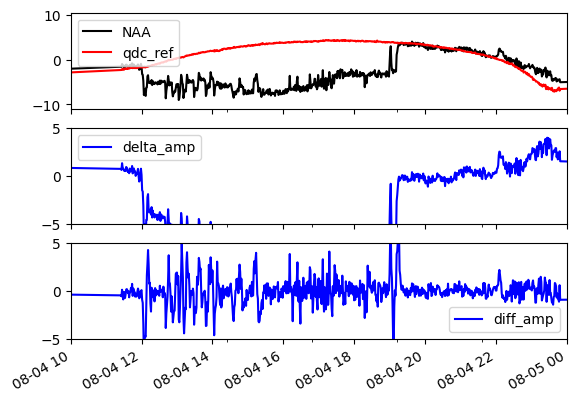

In [20]:
dl1,dl2 = dt.datetime(2025,8,4, 10), dt.datetime(2025,8,5)
#df[["delta_amp","diff_amp"]].plot()
fig = plt.figure()
ax = plt.subplot(311)
df_diurno[["NAA","qdc_ref"]].plot(color=["black", "red"], ax=ax)
#ax2 = ax.twinx()
#ax2.plot(df["GOES18"], color="purple")
#ax2.set_ylim(1e-7, 1e-3)
ax = plt.subplot(312, sharex=ax)
df_diurno[["delta_amp"]].plot(color=["blue"], ax=ax)
ax.set_ylim(-5,5)
ax = plt.subplot(313, sharex=ax)
df_diurno[["diff_amp"]].plot(color=["blue"], ax=ax)
ax.set_ylim(-5,5)
plt.xlim(dl1, dl2)


<Axes: ylabel='Frequency'>

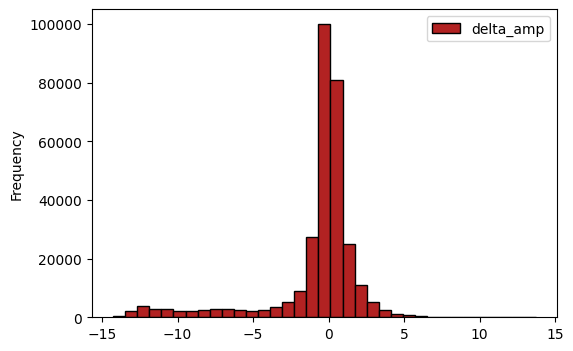

In [26]:
fig, ax = plt.subplots(figsize=(6,4))
# df_diurno[["delta_amp"]].plot(kind ="box", color="b", ax=ax,)
df_diurno[["delta_amp"]].plot(kind ="hist", color="firebrick", ax=ax,bins=35, edgecolor="k")

In [34]:
a = [0,0,0,1,1,1,0,0]
np.pad( np.diff(a), (1,0),)

array([ 0,  0,  0,  1,  0,  0, -1,  0])

In [87]:
_states = df["state"].values

onset_duration = df.index[np.pad(np.diff(_states),(1, 0))==-1] - df.index[np.pad(np.diff(_states),(1, 0))==1]
onset_duration = onset_duration.astype('timedelta64[s]')/np.timedelta64(60,"s" )
onset_duration
# for l in zip(df_diurno.index[np.pad(np.diff(_states),(1, 0))==1] , df_diurno.index[np.pad(np.diff(_states),(1, 0))==-1]):
#     print(l)

688320 688320


ValueError: cannot add indices of unequal length

In [82]:
type(df["state"])

pandas.core.series.Series

In [45]:
_ii = np.argmax(onset_duration)
_ti = df_diurno.index[np.pad(np.diff(_states),(1, 0))==1]
_ti[_ii]

Timestamp('2025-04-04 23:05:00')

In [66]:
%matplotlib inline

Text(0.5, 1.0, 'Onset duration (in minutes)')

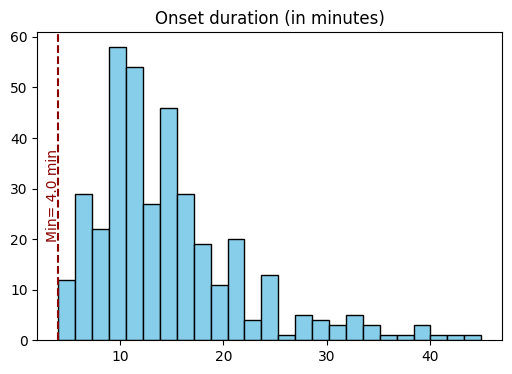

In [80]:
fig = plt.figure(figsize=(6, 4))
plt.hist(onset_duration, bins=25, edgecolor="k", facecolor="skyblue")
min_duration = min(onset_duration) 
plt.axvline(x=min(onset_duration), ls="--", color="darkred")
plt.text(min_duration-1.2, 20, f"Min= {min_duration} min", rotation="vertical", color="darkred")
plt.title("Onset duration (in minutes)")

<Axes: ylabel='Frequency'>

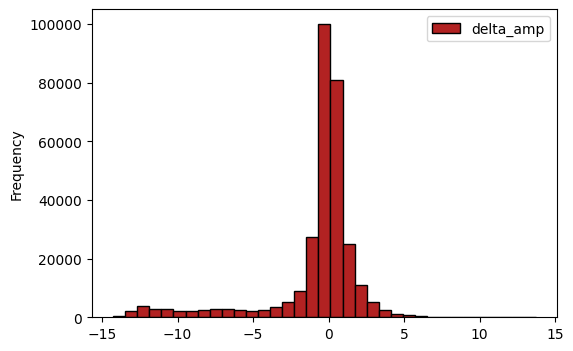

In [74]:
fig, ax = plt.subplots(figsize=(6,4))
# df_diurno[["delta_amp"]].plot(kind ="box", color="b", ax=ax,)
df_diurno[["delta_amp"]].plot(kind ="hist", color="firebrick", ax=ax,bins=35, edgecolor="k")


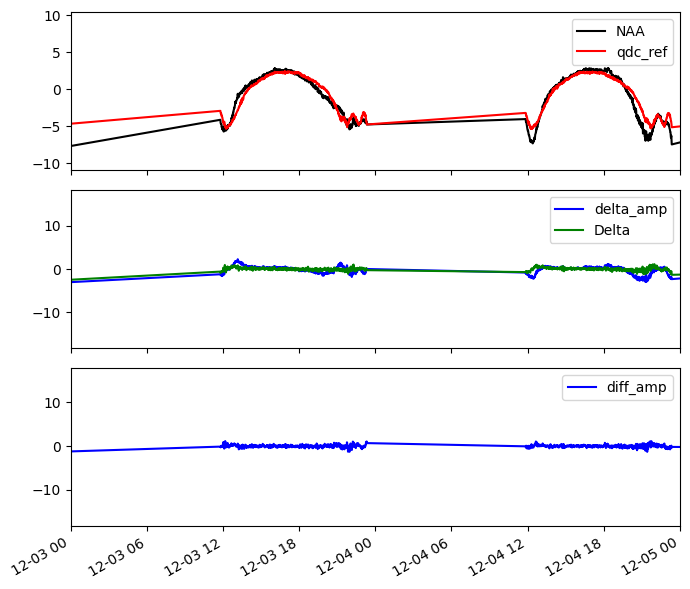

In [45]:

dl1, dl2 = dt.datetime(2025, 12, 3), dt.datetime(2025, 12, 5)

# 1. Creación de subplots
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(7, 6
                                                   ), sharex=True)

# 2. Graficación de señales
df_diurno[["NAA", "qdc_ref"]].plot(color=["black", "red"], ax=ax1)
df_diurno[["delta_amp"]].plot(color=["blue"], ax=ax2)
df_diurno[["Delta"]].plot(color=["green"], ax=ax2)
df_diurno[["diff_amp"]].plot(color=["blue"], ax=ax3)

# 3. Mapeo de colores para cada estado {1, 2}
colores_estado = {
    1: ('red', 0.35, 'Onset (s=1)'),
    2: ('orange', 0.35, 'Decay (s=2)')
}

# 4. Aplicación de las bandas de color en todos los subplots
axes = [ax1, ax2, ax3]

for ax in axes:
    for estado, (color, alpha, label) in colores_estado.items():
        ax.fill_between(
            df_diurno.index, 0, 1,
            where=(df_diurno['state'] == estado),
            color=color, alpha=alpha,
            transform=ax.get_xaxis_transform(),
            step='mid'
        )

# Configuración final
ax1.set_xlim(dl1, dl2)
plt.tight_layout()
plt.show()

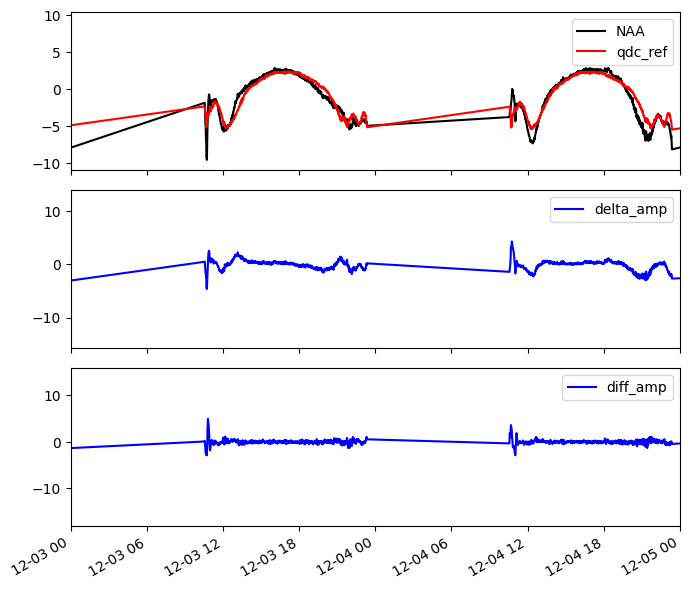

In [43]:
df_diurno.columns

Index(['NAA', 'GOES18', 'state', 'GOES19', 'NAA-filt', 'NAA_dB_bgrm', 'Delta',
       'time', 'date', 'qdc_ref', 'delta_amp', 'diff_amp', 'slope_5m',
       'slope_10m', 'transient', 'rv_5m', 'bp_energy', 'bg_local_60min',
       'delta60min_amp_local', 'diff60min_amp_local', 'bg_local_120min',
       'delta120min_amp_local', 'diff120min_amp_local'],
      dtype='object')

In [46]:
features = ["delta_amp", "diff_amp"]
print("Features used:", features)
X = df_diurno[features].values
y = df_diurno['state'].values # 0: Normal, 1: Rise, 2: Decay
t = df_diurno.index

split_idx = int(0.8 * len(X))
X_train_raw, X_test_raw = X[:split_idx], X[split_idx:]

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)   # fit + transform on train
X_test  = scaler.transform(X_test_raw)        # ONLY transform on test

# scaler = StandardScaler()
# X_scaled = scaler.fit_transform(X)
# # Cortamos al 80% del tiempo.
# split_idx = int(len(X_scaled) * 0.8)

# X_train, X_test = X_scaled[:split_idx], X_scaled[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]
t_train, t_test = t[:split_idx], t[split_idx:]
X_train = np.nan_to_num(X_train, nan=0.0, posinf=10.0, neginf=-10.0)
X_test = np.nan_to_num(X_test, nan=0.0, posinf=10.0, neginf=-10.0)
print(f"Train samples: {len(X_train)} | Test samples: {len(X_test)}")

# Usamos los datos de TRAIN para definir qué es cada estado.

def calculate_mean_and_cov(features, labels):
    unique_labels = np.unique(labels)
    n_states = len(unique_labels)
    n_features = features.shape[1]
    
    means = np.zeros((n_states, n_features))
    covars = np.zeros((n_states, n_features, n_features))
    
    for i, state in enumerate(unique_labels):
        state_data = features[labels == state]
        means[i] = np.mean(state_data, axis=0)
        cov = np.cov(state_data.T)
        min_covar = 1e-4  # Valor pequeño para darle "volumen" a la gaussiana
        cov = cov + np.eye(n_features) * min_covar
        
        cov = (cov + cov.T) / 2
        covars[i] = cov
        
    return means, covars


def calculate_startprob(labels):

    n_states = len(np.unique(labels))
    startprob = np.zeros(n_states)

    initial_state = int(labels[0])
    startprob[initial_state] = 1.0

    return startprob
    
def calculate_transmat(labels):

    n_states = len(np.unique(labels))
    transmat = np.zeros((n_states, n_states))

    # 1. Contar todas las transiciones en la secuencia
    for i in range(len(labels) - 1):
        from_state = int(labels[i])
        to_state = int(labels[i+1])
        transmat[from_state, to_state] += 1

    row_sums = transmat.sum(axis=1, keepdims=True)
    with np.errstate(divide='ignore', invalid='ignore'):
        transmat = np.where(row_sums > 0, transmat / row_sums, 0)
    return transmat

# 
startprob = calculate_startprob(y_train)
transmat = calculate_transmat(y_train)
means, covars = calculate_mean_and_cov(X_train, y_train)
print("Transition Matrix A:\n",transmat)

# init the model
model = hmm.GaussianHMM(
    n_components=2, 
    covariance_type="full", 
    # init_params="smc", # 
    init_params="",
    min_covar=1e-3, 
    n_iter=50,          # Le damos iteraciones para converger
    verbose=True
)

model.startprob_ = startprob
model.transmat_ = transmat
model.means_ = means
model.covars_ = covars

print("\nAfinando parámetros con algoritmo EM...")
model.fit(X_train)

if model.monitor_.converged:
# print("[OK] Model Successfully converged!" if model.monitor_.converged} else "[XX] Model Not connverged!")
    print("[OK] model Converged!")
    fig = plt.figure(figsize=(4,3))
    plt.plot( model.monitor_.history, "-s", color="darkred", markerfacecolor="none")
    #model.monitor_.n_iter
    plt.xlabel("Iter.")
    plt.ylabel("Log-Likelihood")
    plt.title(f"Convergence\n{features}", fontsize=10)
    
    print("\nTransmat\nmodel transmat A:\n", model.transmat_ )
    print("\ninitial transmat\n",transmat)
    y_pred = model.predict(X_test)
    # processing the predicted states: grab time intervals
    rise_pred_intervals     = mu.find_state_intervals(t_test, y_pred,target=1) 
    decay_pred_intervals    = mu.find_state_intervals(t_test, y_pred,target=2) 
    rise_true_intervals     = mu.find_state_intervals(t_test, y_test, target=1)
    decay_true_intervals    = mu.find_state_intervals(t_test, y_test, target=2)
    # validate rise s=1 match - rise_true_intervals
    matchdf_smooth = mu.validate_match(rise_true_intervals, rise_pred_intervals, df_diurno["delta_amp"], -3)
    print("\n", "--"*50)
    print(classification_report(matchdf_smooth["true"], matchdf_smooth["pred"]))
    print("Nueva Matriz de Confusión:")
    print(confusion_matrix(matchdf_smooth["true"], matchdf_smooth["pred"]))
    print("Endr of the training & validation")
else:
    print("[!!] model NOT Converged!\n-> End of the training.")


Features used: ['delta_amp', 'diff_amp']
Train samples: 273007 | Test samples: 68252
Transition Matrix A:
 [[0.99895438 0.00104562]
 [0.06586967 0.93413033]]

Afinando parámetros con algoritmo EM...


         1 -697095.93805003             +nan
         2 -486606.96263402 +210488.97541601
         3 -297944.76505256 +188662.19758146
         4 -289657.54002606   +8287.22502650
         5 -288976.26610513    +681.27392093
         6 -288836.09242314    +140.17368199
         7 -288799.56250911     +36.52991404
         8 -288788.91728303     +10.64522608
         9 -288785.73906844      +3.17821459
        10 -288784.81723694      +0.92183149
        11 -288784.55609143      +0.26114551
        12 -288784.48301406      +0.07307737
        13 -288784.46267905      +0.02033501


[OK] model Converged!

Transmat
model transmat A:
 [[0.97808444 0.02191556]
 [0.00524089 0.99475911]]

initial transmat
 [[0.99895438 0.00104562]
 [0.06586967 0.93413033]]
True events:	 90
Predicted events:	 202

 ----------------------------------------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        24
           1       0.49      0.26      0.34        90

    accuracy                           0.20       114
   macro avg       0.24      0.13      0.17       114
weighted avg       0.39      0.20      0.27       114

Nueva Matriz de Confusión:
[[ 0 24]
 [67 23]]
Endr of the training & validation


        14 -288784.45703320      +0.00564585


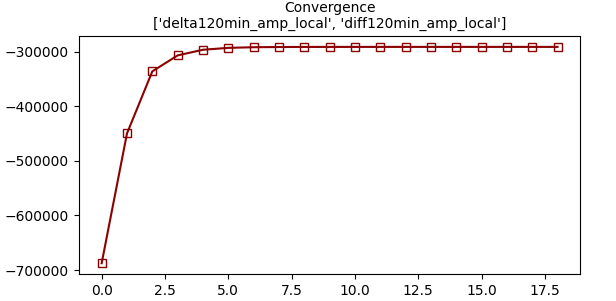

In [149]:
# fig = plt.figure()
# ax = plt.subplot(211)
# plt.plot(model.means_, label="means") 
# plt.legend()
# ax = plt.subplot(212)
# ax.plot(model.covars_, label="covars")
# ax.legend()

In [184]:
#prediction
y_pred = model.predict(X_test)

In [39]:
import importlib
importlib.reload(mu)

<module 'modelutils' from '/home/aldo/solar_flare/modelutils.py'>

### freeze the transmat


In [90]:
%%capture captured_outtext --no-stderr

listoffeatures = [
    ["delta_amp", "diff_amp"], 
    ["delta120min_amp_local", "diff120min_amp_local"], 
    ["delta120min_amp_local", "diff120min_amp_local", "transient"],
    [ "transient"],
]

n_trial = 0
for k, lf in enumerate(listoffeatures):
    print(f"\n==== Trial {k} ==============" )
    features = lf
    print("Features used:", features)
    X = df_diurno[features].values
    y = df_diurno['state'].values # 0: Normal, 1: Rise, 2: Decay
    t = df_diurno.index
    
    split_idx = int(0.8 * len(X))
    X_train_raw, X_test_raw = X[:split_idx], X[split_idx:]
    
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train_raw)   # fit + transform on train
    X_test  = scaler.transform(X_test_raw)        # ONLY transform on test
    
    # scaler = StandardScaler()
    # X_scaled = scaler.fit_transform(X)
    # # Cortamos al 80% del tiempo.
    # split_idx = int(len(X_scaled) * 0.8)
    
    # X_train, X_test = X_scaled[:split_idx], X_scaled[split_idx:]
    y_train, y_test = y[:split_idx], y[split_idx:]
    t_train, t_test = t[:split_idx], t[split_idx:]
    X_train = np.nan_to_num(X_train, nan=0.0, posinf=10.0, neginf=-10.0)
    X_test = np.nan_to_num(X_test, nan=0.0, posinf=10.0, neginf=-10.0)
    print(f"Train samples: {len(X_train)} | Test samples: {len(X_test)}")
    
    # 
    startprob = mu.calculate_startprob(y_train)
    transmat = mu.calculate_transmat(y_train)
    means, covars = mu.calculate_mean_and_cov(X_train, y_train)
    print("Transition Matrix A:\n",transmat)
    
    # init the model
    model = hmm.GaussianHMM(
        n_components=2,
        covariance_type="full",
        init_params="",
        params="mc",          # <-- freeze startprob AND transmat
        min_covar=1e-3,
        n_iter=50,
        verbose=True,
    )
    model.startprob_ = startprob
    model.transmat_ = transmat
    model.means_    = means
    model.covars_   = covars
    
    print("\nAfinando parámetros con algoritmo EM...")
    model.fit(X_train)
    
    if model.monitor_.converged:
    # print("[OK] Model Successfully converged!" if model.monitor_.converged} else "[XX] Model Not connverged!")
        print("[OK] model Converged!")
        fig = plt.figure(figsize=(4,3))
        plt.plot( model.monitor_.history, "-s", color="darkred", markerfacecolor="none")
        #model.monitor_.n_iter
        plt.xlabel("Iter.")
        plt.ylabel("Log-Likelihood")
        plt.title(f"Convergence\n{features}", fontsize=10)
        
        print("\nTransmat\nmodel transmat A:\n", model.transmat_ )
        print("\ninitial transmat\n",transmat)
        y_pred = model.predict(X_test)
        # processing the predicted states: grab time intervals
        rise_pred_intervals     = mu.find_state_intervals(t_test, y_pred,target=1) 
        decay_pred_intervals    = mu.find_state_intervals(t_test, y_pred,target=2) 
        rise_true_intervals     = mu.find_state_intervals(t_test, y_test, target=1)
        decay_true_intervals    = mu.find_state_intervals(t_test, y_test, target=2)
        # validate rise s=1 match - rise_true_intervals
        matchdf_smooth = mu.validate_match(rise_true_intervals, rise_pred_intervals, df_diurno["delta_amp"], -3)
        print("\n", "--"*50)
        print(classification_report(matchdf_smooth["true"], matchdf_smooth["pred"]))
        print("Nueva Matriz de Confusión:")
        print(confusion_matrix(matchdf_smooth["true"], matchdf_smooth["pred"]))
        print("Endr of the training & validation")
    else:
        print("[!!] model NOT Converged!\n-> End of the training.")
    


         1 -693368.23981614             +nan
         2 -550709.85092554 +142658.38889059
         3 -385858.62038510 +164851.23054044
         4 -337815.11480232  +48043.50558278
         5 -335437.71194672   +2377.40285561
         6 -335093.39048211    +344.32146461
         7 -335010.12563231     +83.26484980
         8 -334987.06788331     +23.05774900
         9 -334980.91473272      +6.15315060
        10 -334979.26688918      +1.64784354
        11 -334978.82137229      +0.44551689
        12 -334978.70022997      +0.12114232
        13 -334978.66718415      +0.03304582
        14 -334978.65815103      +0.00903312
         1 -721054.01270793             +nan
         2 -577152.93641238 +143901.07629555
         3 -526267.27255997  +50885.66385241
         4 -502852.12616739  +23415.14639258
         5 -493579.63668765   +9272.48947974
         6 -489323.46524137   +4256.17144628
         7 -487384.80045832   +1938.66478305
         8 -486514.82838738    +869.97207094
         9

In [25]:
with open("train_fixedA_params-mc_alignright.txt", "w") as f:
    f.write(captured_outtext.stdout)

In [96]:
onset_duration_pred = t_test[np.pad(np.diff(y_pred),(1, 0))==-1] - t_test[np.pad(np.diff(y_pred),(1, 0))==1]
onset_duration_pred = onset_duration_pred.astype('timedelta64[s]')/np.timedelta64(60,"s" )
sum(onset_duration_pred<4)

np.int64(9)

In [105]:
ts  = t_test[np.pad(np.diff(y_pred),(1, 0))==1]
print("----1\n", ts[onset_duration_pred==1])
print("----2\n", ts[onset_duration_pred==2])
print("----3\n", ts[onset_duration_pred==3])

----1
 DatetimeIndex(['2026-01-06 15:48:00', '2026-02-17 23:05:00',
               '2026-02-18 18:47:00', '2026-02-20 22:25:00',
               '2026-03-04 14:39:00', '2026-04-07 19:45:00'],
              dtype='datetime64[ns]', freq=None)
----2
 DatetimeIndex(['2026-03-16 18:39:00'], dtype='datetime64[ns]', freq=None)
----3
 DatetimeIndex(['2026-03-28 15:49:00', '2026-04-06 21:38:00'], dtype='datetime64[ns]', freq=None)


Text(0.5, 1.0, 'Onset duration (in minutes)')

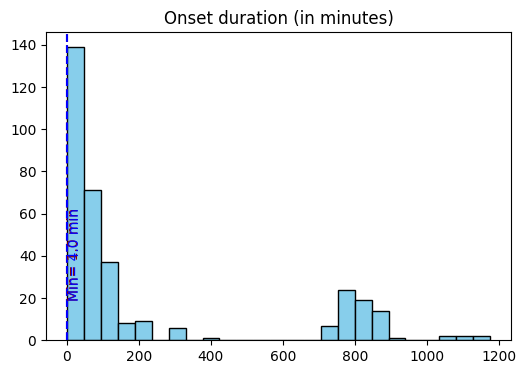

In [100]:
fig = plt.figure(figsize=(6, 4))
plt.hist(onset_duration_pred, bins=25, edgecolor="k", facecolor="skyblue")
min_duration_pred = min(onset_duration_pred) 
plt.axvline(x=min(onset_duration_pred), ls="--", color="darkred")
plt.text(min_duration_pred-1.2, 20, f"Min= {min_duration_pred} min", rotation="vertical", color="darkred")

# min duration true
plt.axvline(x=min(onset_duration), ls="--", color="blue")
plt.text(min_duration-1.2, 20, f"Min= {min_duration} min", rotation="vertical", color="blue")
plt.title("Onset duration (in minutes)")
# plt.xscale("log")#

In [58]:
dl = [
    dt.datetime(2026, 1,1),
    dt.datetime(2026, 4, 10)
    ]

fig, axs = plt.subplots(2,1,sharex=True)
ax0 = axs[0]

#ax0.plot(t_test, X_test[:,0], color="gray", lw=1,label="Signal")
#ax0.plot(t_test, X_test[:,1], color="blue", lw=1, label="Diff. Signal")
ax0.plot(df["NAA"].loc[dl[0]:dl[1]], color="black", lw=1, label="Signal raw")
ax0.plot(df_diurno["delta_amp"].loc[dl[0]:dl[1]], color="navy", lw=1, label="Delta-amp")
ax1 = ax0.twinx()
testmask = (dl[0]<t_test) & (t_test<dl[1])
ax1.plot(t_test[testmask], y_test[testmask], color="red", ls="--", lw=1.5, label="True state")
for t1,t2 in zip(matchdf_smooth["t_pred_1"], matchdf_smooth["t_pred_2"]):
    if not pd.isna(t1):
        ax1.axvspan(t1,t2, color="yellowgreen",alpha=0.6, label="Predicted event")
#plt.legend(l,"Predicted event")
ax0.set_ylabel("Amp. (dB)")

ax0.legend()
ax1.set_ylabel("State")
ax2 = axs[1]
ax2.plot(df['GOES18'].loc[dl[0]:dl[1]], color="purple",label="X rays GOES")
ax2.set_ylabel("Flux (W/m²)")
ax2.set_yscale("log")
ax2.set_xlabel("Time UT")
fig.autofmt_xdate()

In [57]:
plt.close()

In [60]:
print("true events", sum(np.diff(y_test==1) > 0))
print("pred events", sum(np.diff(y_pred==1) > 0))

true events 180
pred events 480


In [48]:
matchdf_smooth

,t_true_1,t_true_2,t_pred_1,t_pred_2,true,pred
0,NaT,NaT,2026-01-04 13:25:00,2026-01-04 13:28:00,0,1
1,NaT,NaT,2026-01-04 21:40:00,2026-01-04 21:46:00,0,1
2,NaT,NaT,2026-01-04 22:28:00,2026-01-04 22:31:00,0,1
3,NaT,NaT,2026-01-05 23:31:00,2026-01-06 12:07:00,0,1
4,NaT,NaT,2026-01-06 12:50:00,2026-01-06 12:53:00,0,1
...,...,...,...,...,...,...
372,NaT,NaT,2026-04-06 19:39:00,2026-04-06 19:42:00,0,1
373,NaT,NaT,2026-04-06 19:44:00,2026-04-06 19:47:00,0,1
374,NaT,NaT,2026-04-06 21:38:00,2026-04-06 21:58:00,0,1
375,NaT,NaT,2026-04-06 22:51:00,2026-04-06 22:58:00,0,1


In [57]:
plt.figure()
plt.plot(t_train, X_train)
plt.legend()

/tmp/ipykernel_8846/1644147617.py:3: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


In [111]:
%matplotlib qt
plt.figure()
ax = plt.subplot()
ax.plot(t_test, df_diurno.loc[t_test, "NAA"], color="black")
ax2 = ax.twinx()
ax2.plot(t_test,y_test, color="forestgreen", alpha=0.75)
ax2.plot(t_test,y_pred, color="red", alpha=0.7)

plt.show()